In [ ]:
import numpy as np
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import scipy.sparse as sparse
import scipy.sparse.linalg as sparsela
import scipy.linalg as sla
import math
from tqdm import tqdm
import time
import numpy.linalg as la 
import pandas as pd
import random
random.seed(7)

import pop_aware
import original

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 12})
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

## One-population Simulation

In [6]:
T =     80.0
Nt =    5000 # number of points
t_grid = np.linspace(0, T, Nt, endpoint=True) # grid on [0,T]
Delta_t = t_grid[1]-t_grid[0]

n_states = 3
n_print=10
epsilon = 1e-1

n_blocks = 1

beta = np.array([0.4])
gamma = np.array([1/7])

c_lambda = np.array([1.])
c_inf = np.array([1.])

graphon = np.array([[1.]])

block_dens = [1.]

p_0 = np.array([[0.99], [0.01], [0.00]])
u_T = np.array([[0], [0], [0]])

lambda_type =1 #Block specific lambdas
death = 0

#unused ones
c_dead = np.array([1., 1.])
rho = np.array([1.0, 1.0])

lambda_s_in = [0.9]
lambda_i_in = [0.9]
lambda_r_in = [0.9]

lambda_duration = np.zeros(0)

kappa = np.array([0.005])
c_nu= np.array([0.001])

V = 1.

In [7]:
# visualization parameters
COLOR = {
    "maroon":   "#800000",
    "darkblue": "#00008B",
    "hunter":   "#355E3B",
    "eggplant": "#4A235A",
    "brown":    "#5D4037",
    "gray":     "#555555",
    "lightgray":"#BBBBBB",
}

color_pool = ["maroon", "darkblue", "hunter", "eggplant", "brown"]
line_pool = ["-", "-.", "--"]
block_names = ['L', 'M', 'H']

In [8]:
cp_S = 0.5
cp_I = 0.5
cp_R = 0.0

debug_single_pop = {}

date = 5
i = 0
debug_single_pop[i] = pop_aware.stoch_block_check_pop_aware(n_blocks, n_states, Nt, lambda_s_in, lambda_i_in, lambda_r_in, \
                  graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu, \
                  t_grid, T, p_0, u_T, n_print, 'Mar{date}_Exp_{id_}'.format(date=date, id_=i), \
                  block_dens, lambda_type, lambda_duration, death, epsilon, V, cp_S, cp_I, cp_R)

i = 1
debug_single_pop[i] = original.stoch_block_check_original(n_blocks, n_states, Nt, lambda_s_in, lambda_i_in, lambda_r_in, \
                  graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu, \
                  t_grid, T, p_0, u_T, n_print, 'Mar{date}_Exp_{id_}'.format(date=date, id_=i), \
                  block_dens, lambda_type, lambda_duration, death, epsilon, V)

cp_S = 1.
cp_I = 1.
cp_R = 0.0

i = 2
debug_single_pop[i] = pop_aware.stoch_block_check_pop_aware(
    n_blocks, n_states, Nt, lambda_s_in, lambda_i_in, lambda_r_in,
    graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu,
    t_grid, T, p_0, u_T, n_print, f'Mar{date}_Exp_{i}',
    block_dens, lambda_type, lambda_duration, death, epsilon, V,
    cp_S, cp_I, cp_R)

iter:  0 p conv:  13.099006288936698 u conv: 474.1262452955482
iter:  10 p conv:  0.26838380636236037 u conv: 1.5363599202846452
iter:  0 p conv:  13.099006288936698 u conv: 465.0972249232244
iter:  10 p conv:  0.2321036682056113 u conv: 1.1783133467503106
iter:  0 p conv:  13.099006288936698 u conv: 484.8033746469271
iter:  10 p conv:  0.2935144302546563 u conv: 1.9696755995417288


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def _downsample(t, y, max_points=Nt):
    """Downsample for fast & light plotting (keeps shape)."""
    n = len(t)
    if n <= max_points:
        return t, y
    stride = max(1, n // max_points)
    return t[::stride], y[..., ::stride] if np.ndim(y) > 1 else y[::stride]

def unpack_result(res, n_blocks=1):
    u = res[0]         
    p = res[1]          
    alpha_s = res[2]    
    nu = res[5]         
    Z = res[6]     

    uS = u[0:n_blocks, :]
    uI = u[n_blocks:2*n_blocks, :]
    uR = u[2*n_blocks:3*n_blocks, :]

    pS = p[0:n_blocks, :]
    pI = p[n_blocks:2*n_blocks, :]
    pR = p[2*n_blocks:3*n_blocks, :]

    return {
        "u": u, "p": p,
        "uS": uS.squeeze(), "uI": uI.squeeze(), "uR": uR.squeeze(),
        "pS": pS.squeeze(), "pI": pI.squeeze(), "pR": pR.squeeze(),
        "alpha_s": alpha_s.squeeze(),
        "nu": nu.squeeze(),
        "Z": Z.squeeze(),
    }

def find_jump_time(t, nu):
    nu_bin = nu
    diff = np.diff(nu_bin)
    jump_idx = np.where(diff != 0)[0]
    if len(jump_idx) == 0:
        return None, None, None
    if len(jump_idx) > 1:
        print(f"multiple jumps detected: {len(jump_idx)}; using the first one.")
    j = int(jump_idx[0])
    return float(t[j+1]), j+1, (int(nu_bin[j]), int(nu_bin[j+1]))

def prettify_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.5, linewidth=0.8, color = 'lavender')
    ax.tick_params(axis="both", which="major", labelsize=11)


In [10]:
def plot_jump_time_comparison(t_grid, scenario_dict, max_points=Nt, savepath=None):
    labels = list(scenario_dict.keys())

    jump_info = []
    for lab in labels:
        tJ, _, trans = find_jump_time(t_grid, scenario_dict[lab]["nu"])
        jump_info.append((tJ, trans))

    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(12.0, 3.8),
        gridspec_kw={"width_ratios": [1.0, 1.4]}
    )

    y = np.arange(len(labels))[::-1]
    for i, lab in enumerate(labels):
        tJ, trans = jump_info[i]
        col = scenario_dict[lab]["_color"]
        yi = y[i]

        if tJ is None:
            axL.plot([0], [yi], marker="x", markersize=8, color=col)
            axL.text(0.02 * (t_grid[-1]), yi, r"no jump", va="center", fontsize=10, color=COLOR["gray"])
            continue

        axL.hlines(yi, 0, tJ, linewidth=2.2, color=col, alpha=0.9)
        axL.plot(tJ, yi, marker="o", markersize=7.5, color=col)
        axL.text(tJ, yi + 0.05, rf"$t^\star={tJ:.2f}$", fontsize=10, color=col, ha="left")

    axL.set_yticks(y)
    axL.set_yticklabels(labels)
    axL.set_xlabel(r"time $t$")
    axL.set_xlim(0, float(t_grid[-1]))
    axL.set_title(r"Vaccination jump time comparison")
    prettify_ax(axL)

    for lab in labels:
        dat = scenario_dict[lab]
        col = dat["_color"]
        nu = dat["nu"]

        tt, nu_ds = _downsample(t_grid, nu, max_points=max_points)
        axR.step(tt, nu_ds, where="post", color=col, linewidth=2.2, label=lab)

        tJ, _, _ = find_jump_time(t_grid, dat["nu"])
        if tJ is not None:
            axR.axvline(tJ, color=col, linestyle="--", linewidth=1.2, alpha=0.55)

    axR.set_ylim(-0.01, V + 0.01)
    axR.set_yticks([0, V])
    axR.set_xlabel(r"time $t$")
    axR.set_ylabel(r"vaccination rate $\nu(t)$")
    axR.set_title(r"Vaccination decision")
    prettify_ax(axR)
    axR.legend(frameon=False, loc="best", fontsize=10)

    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


In [11]:
def plot_uS_with_threshold(t_grid, scenario_dict, c_nu, kappa, max_points=Nt, savepath=None):
    thr = float(c_nu[0] / kappa[0])

    fig, ax = plt.subplots(1, 1, figsize=(9.4, 3.8))

    # uS curves
    for lab, dat in scenario_dict.items():
        col = dat["_color"]
        tt, uS_ds = _downsample(t_grid, dat["uS"], max_points=max_points)
        ax.plot(tt, uS_ds, color=col, linewidth=2.0, label=lab)

        tJ, _, _ = find_jump_time(t_grid, dat["nu"])
        if tJ is not None:
            ax.axvline(tJ, color=col, linestyle="--", linewidth=1.1, alpha=0.55)

    # threshold line
    ax.axhline(thr, color=COLOR["gray"], linestyle="--", linewidth=1.6)
    ax.text(
        0.99 * float(t_grid[-1]), thr,
        rf"$c_\nu/\kappa = {thr:.3f}$",
        ha="right", va="bottom", fontsize=11, color=COLOR["gray"]
    )

    ax.set_xlabel(r"time $t$")
    ax.set_ylabel(r"$u_t(\mathrm{S})$")
    ax.set_title(r"Trajectory of $u_t(\mathrm{S})$ with threshold $c_\nu/\kappa$")
    prettify_ax(ax)
    ax.legend(frameon=False, loc="best", fontsize=10)

    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    return fig

In [12]:
def plot_socialization_and_infection(t_grid, scenario_dict, lambda_s_in, max_points=Nt, savepath=None):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True)

    for lab, dat in scenario_dict.items():
        col = dat["_color"]
        tt, a_ds = _downsample(t_grid, dat["alpha_s"], max_points=max_points)
        ax1.plot(tt, a_ds, color=col, linewidth=2.0, label=lab)

    lam_s = float(lambda_s_in[0])
    ax1.axhline(lam_s, color=COLOR["lightgray"], linestyle=":", linewidth=2.0)
    ax1.text(
        0.995 * float(t_grid[-1]), lam_s,
        rf"$\lambda_t^S={lam_s:.2f}$",
        ha="right", va="bottom", fontsize=10, color=COLOR["gray"]
    )

    ax1.set_ylabel(r"socialization $\hat{\alpha}_t(\mathrm{S})$")
    ax1.set_title(r"Socialization and infection dynamics")
    prettify_ax(ax1)
    ax1.legend(frameon=False, loc="best", fontsize=10)

    for lab, dat in scenario_dict.items():
        col = dat["_color"]
        tt, I_ds = _downsample(t_grid, dat["pI"], max_points=max_points)
        ax2.plot(tt, I_ds, color=col, linewidth=2.0)

    ax2.set_xlabel(r"time $t$")
    ax2.set_ylabel(r"infection level $p_t(\mathrm{I})$")
    prettify_ax(ax2)

    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


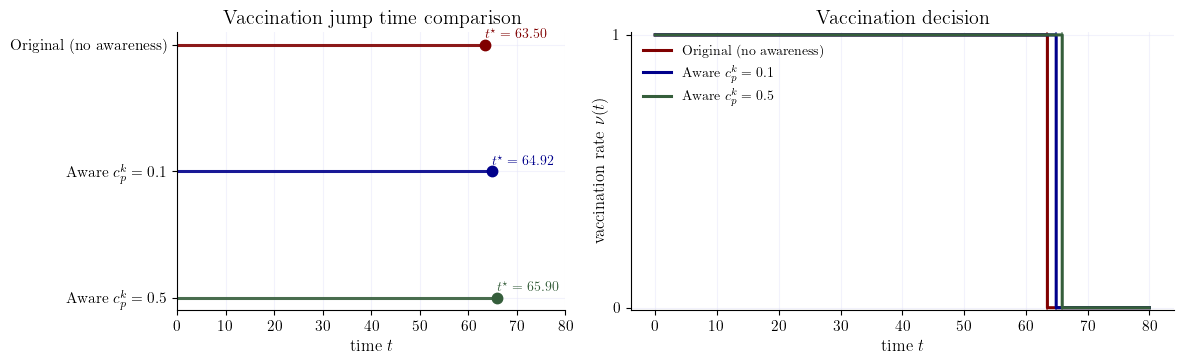

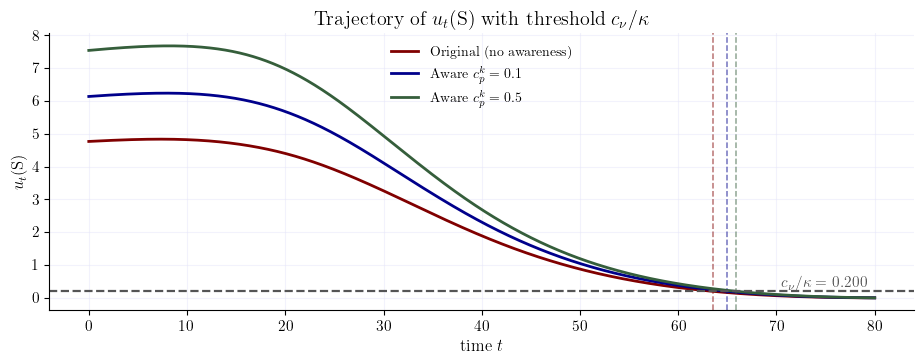

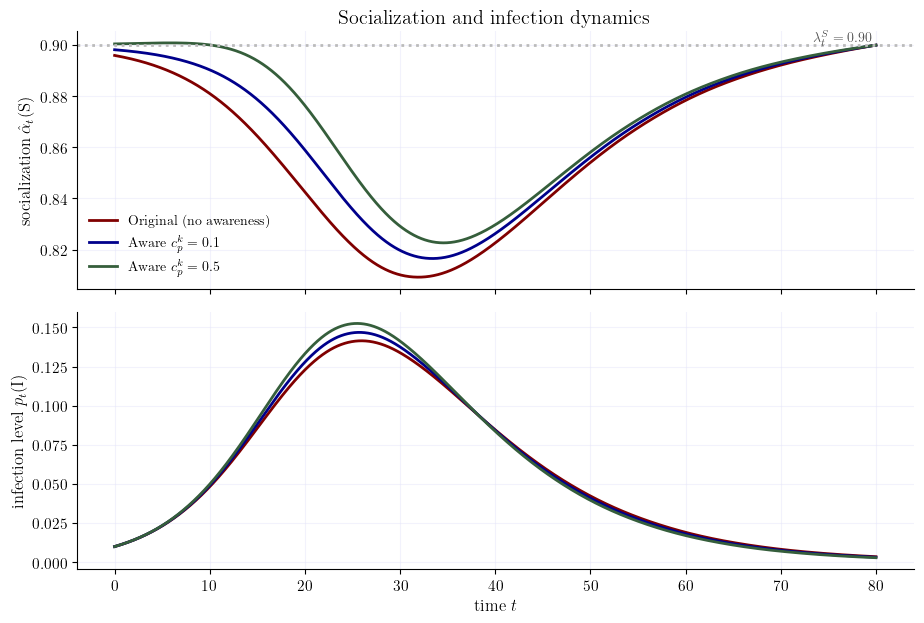

In [13]:
dat_cp01 = unpack_result(debug_single_pop[0], n_blocks=n_blocks)  # aware cp=0.1
dat_base = unpack_result(debug_single_pop[1], n_blocks=n_blocks)  # original
dat_cp05 = unpack_result(debug_single_pop[2], n_blocks=n_blocks)  # aware cp=0.5

scenario = {
    r"Original (no awareness)": dat_base,
    r"Aware $c_p^k=0.1$": dat_cp01,
    r"Aware $c_p^k=0.5$": dat_cp05
}

scenario[r"Aware $c_p^k=0.1$"]["_color"] = COLOR["darkblue"]
scenario[r"Aware $c_p^k=0.5$"]["_color"] = COLOR["hunter"]
scenario[r"Original (no awareness)"]["_color"] = COLOR["maroon"]

fig1 = plot_jump_time_comparison(t_grid, scenario, savepath="e1_jump_time_compare.eps")
fig2 = plot_uS_with_threshold(t_grid, scenario, c_nu=c_nu, kappa=kappa, savepath="e1_uS_threshold.eps")
fig3 = plot_socialization_and_infection(t_grid, scenario, lambda_s_in=lambda_s_in, savepath="e1_socialization_infection.eps")

Grid search: 10×10 = 100 runs
  [  1/100] lambda_S=0.30  lambda_I=0.30


iter:  0 p conv:  2.048223726210547 u conv: 461.3699243798051
  [  2/100] lambda_S=0.30  lambda_I=0.37
iter:  0 p conv:  2.3575635367152694 u conv: 461.3966511057104
  [  3/100] lambda_S=0.30  lambda_I=0.43
iter:  0 p conv:  2.6722456340384086 u conv: 461.42850681172666
  [  4/100] lambda_S=0.30  lambda_I=0.50
iter:  0 p conv:  2.9900575445034345 u conv: 461.4654195000903
  [  5/100] lambda_S=0.30  lambda_I=0.57
iter:  0 p conv:  3.3096385611499377 u conv: 461.50731877800297
  [  6/100] lambda_S=0.30  lambda_I=0.63
iter:  0 p conv:  3.6301031081593815 u conv: 461.5541353532596
  [  7/100] lambda_S=0.30  lambda_I=0.70
iter:  0 p conv:  3.950856421110156 u conv: 461.6058008013773
  [  8/100] lambda_S=0.30  lambda_I=0.77
iter:  0 p conv:  4.271486974516654 u conv: 461.66224744923255
  [  9/100] lambda_S=0.30  lambda_I=0.83
iter:  0 p conv:  4.5917047649865985 u conv: 461.7234083134506
  [ 10/100] lambda_S=0.30  lambda_I=0.90
iter:  0 p conv:  4.911284355001851 u conv: 461.78921706633975
 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Jump time results (lambda_S, lambda_I, t*):
  lambda_S  lambda_I          t*
  ----------------------------
    0.30    0.30      0.0000
    0.30    0.37      0.0000
    0.30    0.43      0.0000
    0.30    0.50      0.0000
    0.30    0.57      0.0000
    0.30    0.63      0.0000
    0.30    0.70      0.0000
    0.30    0.77      0.0000
    0.30    0.83      0.0000
    0.30    0.90      0.0000
    0.37    0.30      0.0000
    0.37    0.37      0.0000
    0.37    0.43      0.0000
    0.37    0.50      0.0000
    0.37    0.57      0.0000
    0.37    0.63      0.0000
    0.37    0.70      0.0000
    0.37    0.77      0.0000
    0.37    0.83      6.4173
    0.37    0.90     14.0028
    0.43    0.30      0.0000
    0.43    0.37      0.0000
    0.43    0.43      0.0000
    0.43    0.50      0.0000
    0.43    0.57      0.0000
    0.43    0.63      0.0000
    0.43    0.70      6.1132
    0.43    0.77     15.4431
    0.43    0.83     24.6609
    0.43    0.90     34.9030
    0.50    0.30     

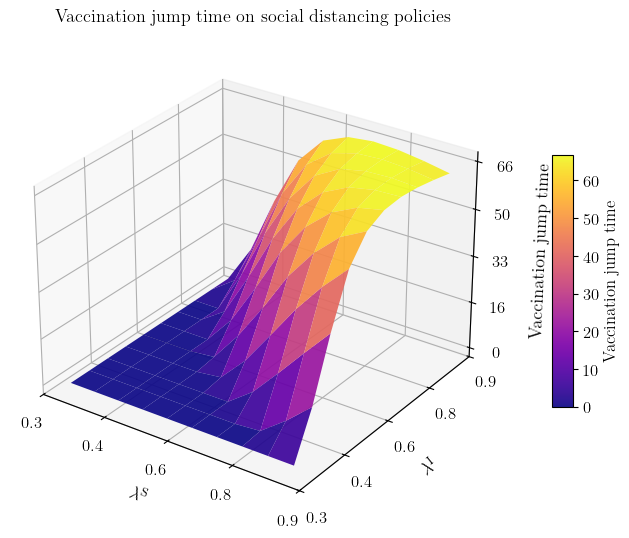

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved → peak_time_3d.eps


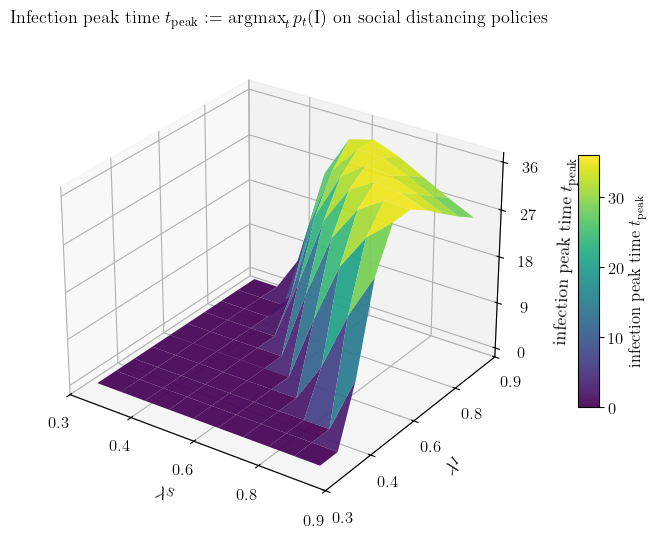

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'font.size': 12, 'pdf.fonttype': 42, 'ps.fonttype': 42})
plt.rc('text', usetex=True)
plt.rc('font', family='serif')


def find_jump_time(t, nu):
    idx = np.where(np.diff(nu) != 0)[0]
    return float(t[idx[0] + 1]) if len(idx) > 0 else 0.0


def find_peak_time(t, pI):
    return float(t[np.argmax(pI)])


def run_grid_search(grid_vals, model_params):
    n = len(grid_vals)
    LS, LI = np.meshgrid(grid_vals, grid_vals, indexing='ij')
    t_jump = np.full((n, n), np.nan)
    t_peak = np.full((n, n), np.nan)

    p = model_params
    total = n * n

    for i, ls in enumerate(grid_vals):
        for j, li in enumerate(grid_vals):
            done = i * n + j + 1
            print(f"  [{done:3d}/{total}] lambda_S={ls:.2f}  lambda_I={li:.2f}", flush=True)

            n_blocks = p['n_blocks']
            ls_in = [ls] * n_blocks
            li_in = [li] * n_blocks
            lr_in = p['lambda_r_in'] if not np.isscalar(p['lambda_r_in']) \
                    else [p['lambda_r_in']] * n_blocks

            try:
                res = original.stoch_block_check_original(
                    n_blocks, p['n_states'], p['Nt'],
                    ls_in, li_in, lr_in,
                    p['graphon'], p['beta'], p['kappa'], p['gamma'], p['rho'],
                    p['c_lambda'], p['c_inf'], p['c_dead'], p['c_nu'],
                    p['t_grid'], p['T'], p['p_0'], p['u_T'],
                    9999, f'grid_ls{ls:.2f}_li{li:.2f}',
                    p['block_dens'], p['lambda_type'], p['lambda_duration'],
                    p['death'], p['epsilon'], p['V'],
                )
            except Exception as e:
                print(f" !! solver failed: {e}")
                continue

            after_p = res[1]   # (n_states*n_blocks, Nt)
            nu      = res[5]   # (n_blocks, Nt)

            bd    = np.array(p['block_dens'])
            pI    = bd @ after_p[n_blocks:2*n_blocks, :]   # aggregate infected
            nu0   = nu[0] if nu.ndim == 2 else nu

            t_jump[i, j] = find_jump_time(p['t_grid'], nu0)
            t_peak[i, j] = find_peak_time(p['t_grid'], pI)

    print("\nJump time results (lambda_S, lambda_I, t*):")
    print(f"  {'lambda_S':>6}  {'lambda_I':>6}  {'t*':>10}")
    print("  " + "-" * 28)
    for i, ls in enumerate(grid_vals):
        for j, li in enumerate(grid_vals):
            val = t_jump[i, j]
            val_str = f"{val:10.4f}" if not np.isnan(val) else "       NaN"
            print(f"  {ls:6.2f}  {li:6.2f}  {val_str}")
    print()

    return LS, LI, t_jump, t_peak



def plot_surface(LS, LI, Z, zlabel, title, cmap, savepath=None, elev=28, azim=-55):
    """Single adaptive 3D surface plot."""
    fig = plt.figure(figsize=(7.5, 5.5))
    ax  = fig.add_subplot(111, projection='3d')

    z_min, z_max = np.nanmin(Z), np.nanmax(Z)
    z_pad = (z_max - z_min) * 0.05 or 1.0

    Zplot = np.where(np.isnan(Z), np.nanmean(Z), Z)

    surf = ax.plot_surface(LS, LI, Zplot, cmap=cmap,
                           vmin=z_min, vmax=z_max,
                           linewidth=0, antialiased=True, alpha=0.92)

    nan_mask = np.isnan(Z)
    if nan_mask.any():
        ax.scatter(LS[nan_mask], LI[nan_mask],
                   np.full(nan_mask.sum(), z_min - z_pad),
                   color='k', s=18, zorder=5, label='no solution')

    cb = fig.colorbar(surf, ax=ax, shrink=0.52, aspect=12, pad=0.08)
    cb.set_label(zlabel, fontsize=12)

    ax.set_xlabel(r"$\lambda^{\mathrm{S}}$", fontsize=13, labelpad=8)
    ax.set_ylabel(r"$\lambda^{\mathrm{I}}$", fontsize=13, labelpad=8)
    ax.set_zlabel(zlabel,         fontsize=13, labelpad=8)
    ax.set_title(title, fontsize=13, pad=12)

    ax.set_zlim(z_min - z_pad, z_max + z_pad)
    ax.set_zticks(np.linspace(z_min, z_max, 5))
    fmt = '%d' if z_max > 10 else '%.2f'
    ax.zaxis.set_major_formatter(plt.FormatStrFormatter(fmt))
    ax.xaxis.set_major_locator(LinearLocator(5))
    ax.yaxis.set_major_locator(LinearLocator(5))
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    ax.view_init(elev=elev, azim=azim)
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, bbox_inches='tight', dpi=150)
        print(f"Saved → {savepath}")
    plt.show()
    return fig



def grid_search_and_plot(
    model_params,
    n_grid     = 10,
    lam_range  = (0.2, 0.9),
    save_jump  = "jump_time_3d.eps",
    save_peak  = "peak_time_3d.eps",
):
    grid_vals = np.linspace(lam_range[0], lam_range[1], n_grid)
    print(f"Grid search: {n_grid}×{n_grid} = {n_grid**2} runs")

    LS, LI, t_jump, t_peak = run_grid_search(grid_vals, model_params)

    fig1 = plot_surface(LS, LI, t_jump,
                        zlabel=r"Vaccination jump time",
                        title="Vaccination jump time on social distancing policies",
                        cmap=cm.plasma, savepath=save_jump)

    fig2 = plot_surface(LS, LI, t_peak,
                        zlabel=r"infection peak time $t_{\mathrm{peak}}$",
                        title=r"Infection peak time $t_{\mathrm{peak}} := \mathrm{argmax}_t \, p_t(\mathrm{I})$ on social distancing policies",
                        cmap=cm.viridis, savepath=save_peak)

    return fig1, fig2, LS, LI, t_jump, t_peak


model_params = dict(
    n_blocks       = 1,
    n_states       = n_states,
    Nt             = Nt,
    lambda_r_in    = lambda_r_in,
    graphon        = graphon,
    beta           = beta,
    kappa          = kappa,
    gamma          = gamma,
    rho            = rho,
    c_lambda       = c_lambda,
    c_inf          = c_inf,
    c_dead         = c_dead,
    c_nu           = c_nu,
    t_grid         = t_grid,
    T              = T,
    p_0            = p_0,
    u_T            = u_T,
    block_dens     = block_dens,
    lambda_type    = lambda_type,
    lambda_duration= lambda_duration,
    death          = death,
    epsilon        = epsilon,
    V              = V,
)

fig1, fig2, LS, LI, t_jump, t_peak = grid_search_and_plot(
    model_params,
    n_grid    = 10,
    lam_range = (0.3, 0.9),
)

In [17]:
def run_grid_search(grid_vals, model_params):
    n = len(grid_vals)
    LS, LI = np.meshgrid(grid_vals, grid_vals, indexing='ij')

    t_jump      = np.full((n, n), np.nan)
    t_peak_time = np.full((n, n), np.nan)
    pI_peak     = np.full((n, n), np.nan)
    alpha_min   = np.full((n, n), np.nan)

    p = model_params
    total = n * n

    for i, ls in enumerate(grid_vals):
        for j, li in enumerate(grid_vals):
            done = i * n + j + 1
            print(f"  [{done:3d}/{total}] lambda_S={ls:.2f}  lambda_I={li:.2f}", flush=True)

            n_blocks = p['n_blocks']
            ls_in = [ls] * n_blocks
            li_in = [li] * n_blocks
            lr_in = p['lambda_r_in'] if not np.isscalar(p['lambda_r_in']) \
                    else [p['lambda_r_in']] * n_blocks

            try:
                res = original.stoch_block_check_original(
                    n_blocks, p['n_states'], p['Nt'],
                    ls_in, li_in, lr_in,
                    p['graphon'], p['beta'], p['kappa'], p['gamma'], p['rho'],
                    p['c_lambda'], p['c_inf'], p['c_dead'], p['c_nu'],
                    p['t_grid'], p['T'], p['p_0'], p['u_T'],
                    9999, f'grid_ls{ls:.2f}_li{li:.2f}',
                    p['block_dens'], p['lambda_type'], p['lambda_duration'],
                    p['death'], p['epsilon'], p['V'],
                )
            except Exception as e:
                print(f"    !! solver failed: {e}")
                continue

            after_p = res[1]
            nu      = res[5] 
            alpha   = res[2]

            bd  = np.array(p['block_dens'])
            pI  = bd @ after_p[n_blocks:2*n_blocks, :]
            nu0 = nu[0] if np.ndim(nu) == 2 else nu

            alpha0 = alpha[0] if np.ndim(alpha) == 2 else alpha

            t_jump[i, j]      = find_jump_time(p['t_grid'], nu0)
            t_peak_time[i, j] = find_peak_time(p['t_grid'], pI)
            pI_peak[i, j]     = np.max(pI)
            alpha_min[i, j]   = np.min(alpha0)

    return LS, LI, t_jump, t_peak_time, pI_peak, alpha_min


def grid_search_and_plot(
    model_params,
    n_grid        = 10,
    lam_range     = (0.2, 0.9),
    save_jump     = "e1_jump_time_3d.eps",
    save_peak_t   = "e1_peak_time_3d.eps",
    save_peak_pI  = "e1_peak_proportion_3d.eps",
    save_alpha_min= "alpha_min_3d.eps",
):
    grid_vals = np.linspace(lam_range[0], lam_range[1], n_grid)
    print(f"Grid search: {n_grid}×{n_grid} = {n_grid**2} runs")

    LS, LI, t_jump, t_peak_time, pI_peak, alpha_min = run_grid_search(grid_vals, model_params)

    fig1 = plot_surface(
        LS, LI, t_jump,
        zlabel=r"Vaccination jump time",
        title=r"Vaccination jump time on social distancing policies",
        cmap=cm.plasma,
        savepath=save_jump
    )

    fig2 = plot_surface(
        LS, LI, t_peak_time,
        zlabel=r"Infection peak time $t_{\mathrm{peak}}$",
        title=r"Infection peak time $t_{\mathrm{peak}} := \arg\max_t p_t(\mathrm{I})$ on social distancing policies",
        cmap=cm.viridis,
        savepath=save_peak_t
    )

    fig3 = plot_surface(
        LS, LI, pI_peak,
        zlabel=r"Infection peak proportion",
        title=r"Infection peak proportion $\max_t p_t(\mathrm{I})$ on social distancing policies",
        cmap=cm.inferno,
        savepath=save_peak_pI
    )

    fig4 = plot_surface(
        LS, LI, alpha_min,
        zlabel=r"Minimum socialization level",
        title=r"Minimum socialization level $\min_t \alpha_t$ on social distancing policies",
        cmap=cm.cividis,
        savepath=save_alpha_min, elev=20, azim=-80
    )

    return fig1, fig2, fig3, fig4, LS, LI, t_jump, t_peak_time, pI_peak, alpha_min

Grid search: 10×10 = 100 runs
  [  1/100] lambda_S=0.30  lambda_I=0.30
iter:  0 p conv:  2.048223726210547 u conv: 461.3699243798051
  [  2/100] lambda_S=0.30  lambda_I=0.37
iter:  0 p conv:  2.3575635367152694 u conv: 461.3966511057104
  [  3/100] lambda_S=0.30  lambda_I=0.43
iter:  0 p conv:  2.6722456340384086 u conv: 461.42850681172666
  [  4/100] lambda_S=0.30  lambda_I=0.50
iter:  0 p conv:  2.9900575445034345 u conv: 461.4654195000903
  [  5/100] lambda_S=0.30  lambda_I=0.57
iter:  0 p conv:  3.3096385611499377 u conv: 461.50731877800297
  [  6/100] lambda_S=0.30  lambda_I=0.63
iter:  0 p conv:  3.6301031081593815 u conv: 461.5541353532596
  [  7/100] lambda_S=0.30  lambda_I=0.70
iter:  0 p conv:  3.950856421110156 u conv: 461.6058008013773
  [  8/100] lambda_S=0.30  lambda_I=0.77
iter:  0 p conv:  4.271486974516654 u conv: 461.66224744923255
  [  9/100] lambda_S=0.30  lambda_I=0.83
iter:  0 p conv:  4.5917047649865985 u conv: 461.7234083134506
  [ 10/100] lambda_S=0.30  lambda_

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved → e1_jump_time_3d.eps


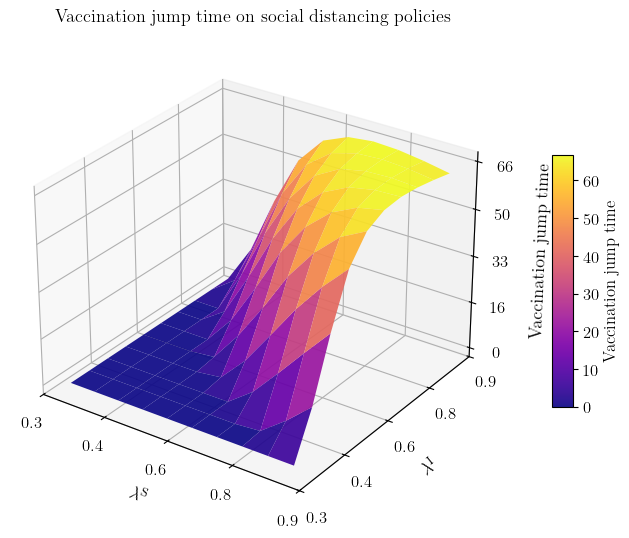

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved → e1_peak_time_3d.eps


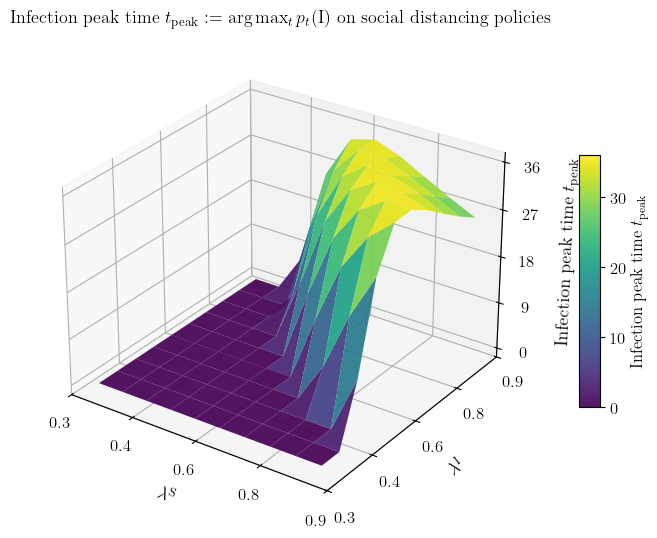

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved → e1_peak_proportion_3d.eps


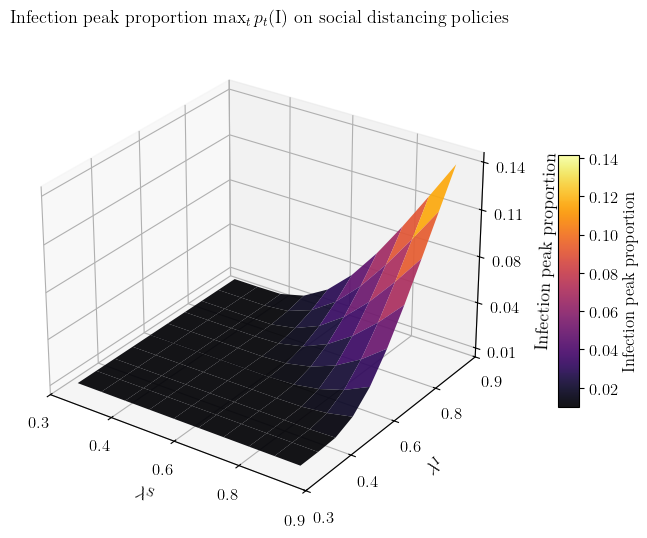

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved → alpha_min_3d.eps


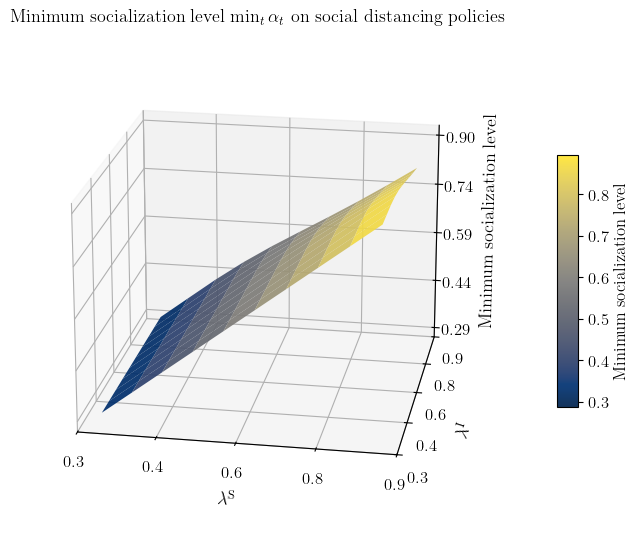

In [18]:
fig1, fig2, fig3, fig4, LS, LI, t_jump, t_peak_time, pI_peak, alpha_min = grid_search_and_plot(
    model_params,
    n_grid    = 10,
    lam_range = (0.3, 0.9),
)

In [19]:
def plot_heatmap(LS, LI, Z, clabel, title, cmap='viridis', savepath=None):
    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    x = LS[:, 0]
    y = LI[0, :]

    Zplot = np.array(Z, dtype=float)

    im = ax.imshow(
        Zplot.T,
        origin='lower',
        aspect='auto',
        extent=[x.min(), x.max(), y.min(), y.max()],
        cmap=cmap
    )

    cb = fig.colorbar(im, ax=ax)
    cb.set_label(clabel, fontsize=12)

    ax.set_xlabel(r"$\lambda^{\mathrm{S}}$", fontsize=13)
    ax.set_ylabel(r"$\lambda^{\mathrm{I}}$", fontsize=13)
    ax.set_title(title, fontsize=13)

    ax.set_xticks(np.linspace(x.min(), x.max(), 5))
    ax.set_yticks(np.linspace(y.min(), y.max(), 5))
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, bbox_inches='tight', dpi=150)
        print(f"Saved to {savepath}")

    plt.show()
    return fig

Saved to e1_alpha_min_heatmap.eps


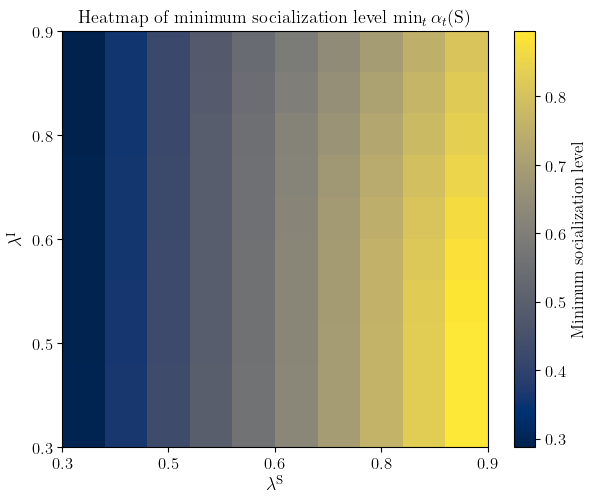

In [20]:
fig5 = plot_heatmap(
    LS, LI, alpha_min,
    clabel=r"Minimum socialization level",
    title=r"Heatmap of minimum socialization level $\min_t \alpha_t(\mathrm{S})$",
    cmap='cividis',
    savepath="e1_alpha_min_heatmap.eps",
)

## Real Implication

In [21]:
n_blocks = 3

beta = np.array([0.4, 0.35, 0.3])
kappa = np.array([0.003, 0.003, 0.003])
gamma = np.array([1/7, 1/7, 1/7])

block_dens = [0.1473 + 0.1751, 0.1509 + 0.1655, 0.1859 + 0.1753]
c_inf = np.array([1.05, 1, 0.8])
c_nu = 0.1*np.array([0.15, 0.13, 0.09]) 
c_lambda = np.array([1., 1., 1.])

p_0 = np.array([[0.99], [0.99], [0.99], 
                [0.01], [0.01], [0.01], 
                [0.00], [0.00], [0.00]])
u_T = np.array([[0], [0], [0],
                [0], [0], [0],
                [0], [0], [0]])
lambda_type =1
death = 0 

graphon = np.array([[1.0, 0.925, 0.925],
                    [0.925, 1.0, 0.925],
                    [0.925, 0.925, 1.0]])

lambda_s_in = [0.9, 0.9, 0.9]
lambda_i_in = [0.9, 0.9, 0.9]
lambda_r_in = [0.9, 0.9, 0.9]

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COLOR = {
    "maroon":   "#800000",
    "darkblue": "#00008B",
    "hunter":   "#355E3B",
    "eggplant": "#4A235A",
    "brown":    "#5D4037",
    "gray":     "#555555",
    "lightgray":"#BBBBBB",
}

GROUP_NAMES  = ["Low income", "Middle income", "High income"]
GROUP_COLORS = [COLOR["maroon"], COLOR["darkblue"], COLOR["hunter"]]

def prettify_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.5, linewidth=0.8, color="lavender")
    ax.tick_params(axis="both", which="major", labelsize=11)

def _stride(n, max_points):
    if (max_points is None) or (n <= max_points):
        return 1
    return max(1, n // max_points)

def extract_SIR_from_p(p, n_blocks):
    S = p[0:n_blocks, :]
    I = p[n_blocks:2*n_blocks, :]
    R = p[2*n_blocks:3*n_blocks, :]
    return S, I, R

def recompute_Z_alpha_nu(u, p, *, n_blocks, block_dens, graphon,
                         lambda_s_in, lambda_i_in, beta, c_lambda,
                         kappa, c_nu, V=1.0):
    block_dens = np.asarray(block_dens, dtype=float).reshape(n_blocks, )
    lambda_s   = np.asarray(lambda_s_in, dtype=float).reshape(n_blocks, )
    lambda_i   = np.asarray(lambda_i_in, dtype=float).reshape(n_blocks, )

    beta     = np.asarray(beta, dtype=float).reshape(n_blocks, )
    c_lambda = np.asarray(c_lambda, dtype=float).reshape(n_blocks, )
    kappa    = np.asarray(kappa, dtype=float).reshape(n_blocks, )
    c_nu     = np.asarray(c_nu, dtype=float).reshape(n_blocks, )

    I = p[n_blocks:2*n_blocks, :]

    Z = graphon @ ((block_dens * lambda_i).reshape(n_blocks, 1) * I)

    uS = u[0:n_blocks, :]
    uI = u[n_blocks:2*n_blocks, :]
    uR = u[2*n_blocks:3*n_blocks, :]

    alpha_s = lambda_s.reshape(n_blocks, 1) + (beta/(2*c_lambda)).reshape(n_blocks, 1) * Z * (uS - uI)

    diff_SR = uS - uR
    thresh  = kappa.reshape(n_blocks, 1) * diff_SR
    nu      = (thresh > c_nu.reshape(n_blocks, 1)).astype(float) * float(V)

    return Z, alpha_s, nu

def prepare_series(res, *, t_grid, n_blocks, block_dens, graphon,
                   lambda_s_in, lambda_i_in, beta, c_lambda,
                   kappa, c_nu, V=1.0, max_points=8000):
    u = np.asarray(res[0], dtype=float)
    p = np.asarray(res[1], dtype=float)

    Nt = p.shape[1]
    s = _stride(Nt, max_points=max_points)
    idx = slice(None, None, s)

    _, alpha_s, nu = recompute_Z_alpha_nu(
        u, p, n_blocks=n_blocks, block_dens=block_dens, graphon=graphon,
        lambda_s_in=lambda_s_in, lambda_i_in=lambda_i_in,
        beta=beta, c_lambda=c_lambda, kappa=kappa, c_nu=c_nu, V=V
    )

    S, I, R = extract_SIR_from_p(p, n_blocks)

    return {
        "t": t_grid[idx],
        "S": S[:, idx],
        "I": I[:, idx],
        "R": R[:, idx],
        "alpha": alpha_s[:, idx],
        "nu": nu[:, idx],
        "V": float(V),
    }


In [23]:
def plot_five_panel_compare(series_A, series_B, *,
                            label_A, label_B,
                            group_names=GROUP_NAMES, group_colors=GROUP_COLORS,
                            suptitle=None, savepath=None):
    t = series_A["t"]
    assert np.allclose(t, series_B["t"]), "t grids differ (use same t_grid + same max_points)."

    V = series_A["V"]
    lsA, lsB = "-", "--"

    fig = plt.figure(figsize=(13.0, 7.6))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.15], hspace=0.30, wspace=0.22)

    axS  = fig.add_subplot(gs[0, 0])
    axI  = fig.add_subplot(gs[0, 1], sharex=axS)
    axR  = fig.add_subplot(gs[1, 0], sharex=axS)
    axA  = fig.add_subplot(gs[1, 1], sharex=axS)
    axNu = fig.add_subplot(gs[2, :], sharex=axS)

    axes = [axS, axI, axR, axA, axNu]

    def _plot_state(ax, key, ylabel, ylim=None):
        for k, (gname, col) in enumerate(zip(group_names, group_colors)):
            ax.plot(t, series_A[key][k, :], color=col, lw=1.6, ls=lsA)
            ax.plot(t, series_B[key][k, :], color=col, lw=1.6, ls=lsB)
        ax.set_ylabel(ylabel)
        if ylim is not None:
            ax.set_ylim(*ylim)
        prettify_ax(ax)

    _plot_state(axS, "S", r"$p_t(\mathrm{S})$", ylim=(0, 1))
    _plot_state(axI, "I", r"$p_t(\mathrm{I})$")
    _plot_state(axR, "R", r"$p_t(\mathrm{R})$", ylim=(0, 1))

    for k, col in enumerate(group_colors):
        axA.plot(t, series_A["alpha"][k, :], color=col, lw=1.6, ls=lsA)
        axA.plot(t, series_B["alpha"][k, :], color=col, lw=1.6, ls=lsB)
    axA.set_ylabel(r"$\hat{\alpha}_t(\mathrm{S})$")
    prettify_ax(axA)

    for k, col in enumerate(group_colors):
        axNu.step(t, series_A["nu"][k, :], where="post", color=col, lw=1.6, ls=lsA)
        axNu.step(t, series_B["nu"][k, :], where="post", color=col, lw=1.6, ls=lsB)
    axNu.set_ylabel(r"$\hat{\nu}(t)$")
    axNu.set_xlabel(r"time $t$")
    axNu.set_ylim(-0.05*V, 1.05*V)
    axNu.set_yticks([0, V])
    axNu.set_yticklabels([r"$0$", rf"${V:g}$"])
    prettify_ax(axNu)

    group_handles = [Line2D([0], [0], color=c, lw=2, ls="-") for c in group_colors]
    policy_handles = [
        Line2D([0], [0], color="black", lw=2.0, ls=lsA),
        Line2D([0], [0], color="black", lw=2.0, ls=lsB),
    ]

    fig.legend(group_handles, group_names, ncol=3, frameon=False,
               loc="upper center", bbox_to_anchor=(0.5, 1.01))
    fig.legend(policy_handles, [label_A, label_B], ncol=2, frameon=False,
               loc="upper center", bbox_to_anchor=(0.5, 0.965))

    if suptitle is not None:
        fig.suptitle(suptitle, y=1.06, fontsize=14)

    fig.tight_layout(rect=[0, 0, 1, 0.94])

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


iter:  0 p conv:  19.333674614390887 u conv: 768.658048106314
iter:  10 p conv:  0.29601171412871274 u conv: 1.2095525858476373
iter:  0 p conv:  13.442595061859263 u conv: 766.1604675484758
iter:  10 p conv:  0.3375118465035335 u conv: 3.197688807819838


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


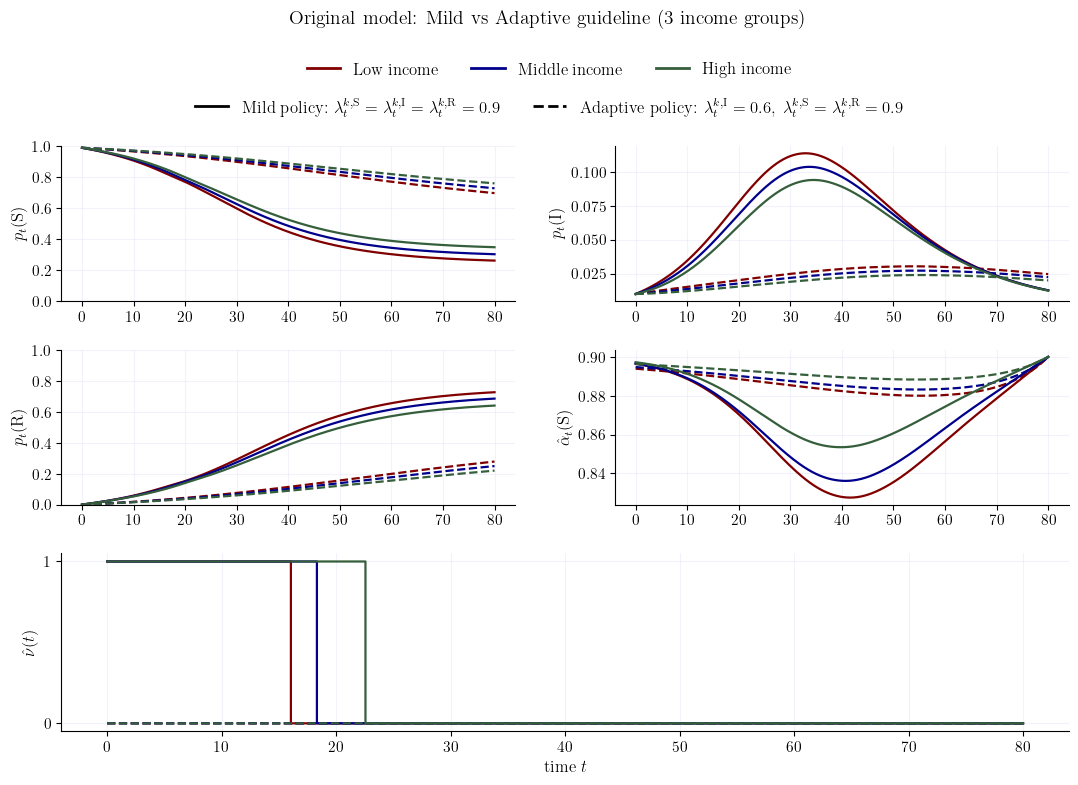

In [24]:
# Case 1: mild vs adaptive (lambda change)
lambda_s_mild = [0.9, 0.9, 0.9]
lambda_i_mild = [0.9, 0.9, 0.9]
lambda_r_mild = [0.9, 0.9, 0.9]

lambda_s_adap = [0.9, 0.9, 0.9]
lambda_i_adap = [0.6, 0.6, 0.6]
lambda_r_adap = [0.9, 0.9, 0.9]

res_mild = original.stoch_block_check_original(
    n_blocks, n_states, Nt,
    lambda_s_mild, lambda_i_mild, lambda_r_mild,
    graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu,
    t_grid, T, p_0, u_T, n_print, "mild_policy",
    block_dens, lambda_type, lambda_duration, death, epsilon, V
)

res_adap = original.stoch_block_check_original(
    n_blocks, n_states, Nt,
    lambda_s_adap, lambda_i_adap, lambda_r_adap,
    graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu,
    t_grid, T, p_0, u_T, n_print, "adaptive_policy",
    block_dens, lambda_type, lambda_duration, death, epsilon, V
)

series_mild = prepare_series(
    res_mild, t_grid=t_grid, n_blocks=n_blocks,
    block_dens=block_dens, graphon=graphon,
    lambda_s_in=lambda_s_mild, lambda_i_in=lambda_i_mild,
    beta=beta, c_lambda=c_lambda, kappa=kappa, c_nu=c_nu, V=V,
    max_points=None
)

series_adap = prepare_series(
    res_adap, t_grid=t_grid, n_blocks=n_blocks,
    block_dens=block_dens, graphon=graphon,
    lambda_s_in=lambda_s_adap, lambda_i_in=lambda_i_adap,
    beta=beta, c_lambda=c_lambda, kappa=kappa, c_nu=c_nu, V=V,
    max_points=None
)

fig1 = plot_five_panel_compare(
    series_mild, series_adap,
    label_A=r"Mild policy: $\lambda_t^{k,\mathrm{S}}=\lambda_t^{k,\mathrm{I}}=\lambda_t^{k,\mathrm{R}}=0.9$",
    label_B=r"Adaptive policy: $\lambda_t^{k,\mathrm{I}}=0.6,\ \lambda_t^{k,\mathrm{S}}=\lambda_t^{k,\mathrm{R}}=0.9$",
    suptitle="Original model: Mild vs Adaptive guideline (3 income groups)",
    savepath="e2_fig_policy_compare.eps"
)


iter:  0 p conv:  19.333674614390887 u conv: 768.658048106314
iter:  10 p conv:  0.29601171412871274 u conv: 1.2095525858476373
iter:  0 p conv:  19.333674614390887 u conv: 768.658048106314


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


iter:  10 p conv:  0.48348092691242456 u conv: 1.9791539445220063


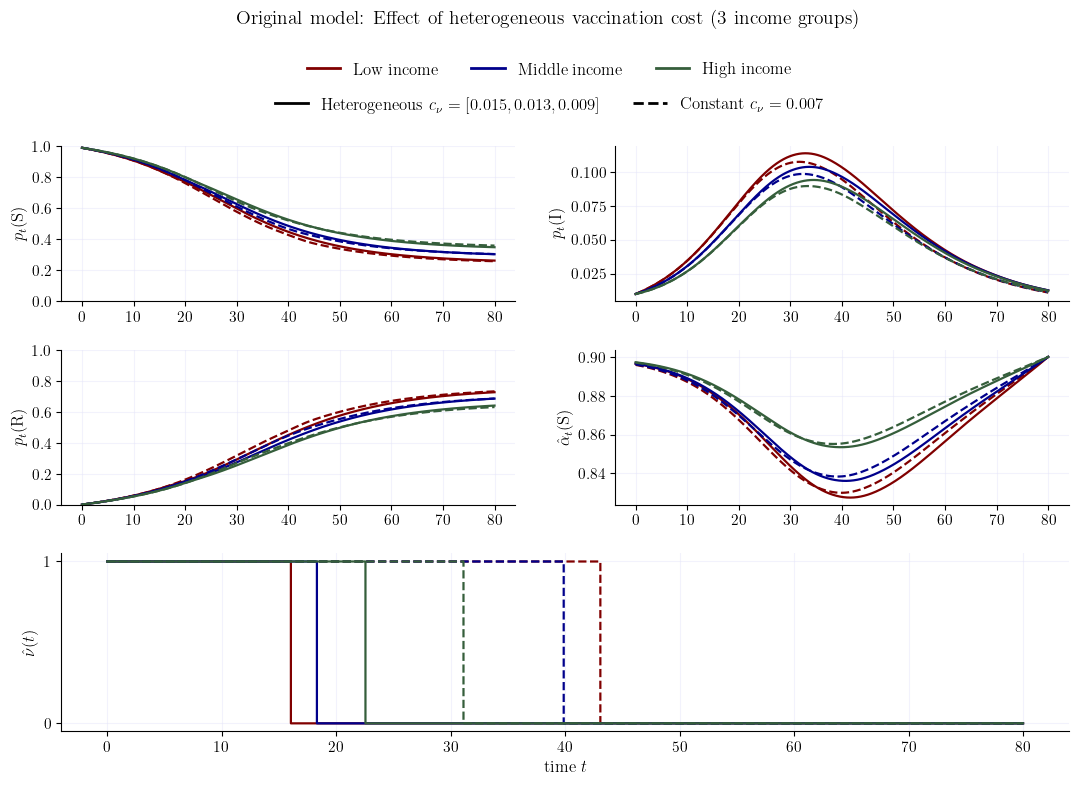

In [26]:
# Case 2: heterogeneous c_nu vs constant c_nu (under mild lambda)
c_nu_heter = 0.1*np.array([0.15, 0.13, 0.09])
c_nu_const = 0.1*np.array([0.07, 0.07, 0.07])

res_cnu_heter = original.stoch_block_check_original(
    n_blocks, n_states, Nt,
    lambda_s_mild, lambda_i_mild, lambda_r_mild,
    graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu_heter,
    t_grid, T, p_0, u_T, n_print, "cnu_heter",
    block_dens, lambda_type, lambda_duration, death, epsilon, V
)

res_cnu_const = original.stoch_block_check_original(
    n_blocks, n_states, Nt,
    lambda_s_mild, lambda_i_mild, lambda_r_mild,
    graphon, beta, kappa, gamma, rho, c_lambda, c_inf, c_dead, c_nu_const,
    t_grid, T, p_0, u_T, n_print, "cnu_const",
    block_dens, lambda_type, lambda_duration, death, epsilon, V
)

series_cnu_heter = prepare_series(
    res_cnu_heter, t_grid=t_grid, n_blocks=n_blocks,
    block_dens=block_dens, graphon=graphon,
    lambda_s_in=lambda_s_mild, lambda_i_in=lambda_i_mild,
    beta=beta, c_lambda=c_lambda, kappa=kappa, c_nu=c_nu_heter, V=V,
    max_points=None
)

series_cnu_const = prepare_series(
    res_cnu_const, t_grid=t_grid, n_blocks=n_blocks,
    block_dens=block_dens, graphon=graphon,
    lambda_s_in=lambda_s_mild, lambda_i_in=lambda_i_mild,
    beta=beta, c_lambda=c_lambda, kappa=kappa, c_nu=c_nu_const, V=V,
    max_points=None
)

fig2 = plot_five_panel_compare(
    series_cnu_heter, series_cnu_const,
    label_A=r"Heterogeneous $c_\nu=[0.015,0.013,0.009]$",
    label_B=r"Constant $c_\nu=0.007$",
    suptitle="Original model: Effect of heterogeneous vaccination cost (3 income groups)",
    savepath="e2_fig_cnu_compare.eps"
)
